# VISION TASK: TRAFFIC SIGN CLASSIFICATION
# Student: Satya Shrestha
# Course: 6CS012 - AI and Machine Learning



# CELL 1: IMPORT LIBRARIES


In [4]:
# ============================================
# CELL 1: IMPORT LIBRARIES
# ============================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import gc
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.utils import shuffle
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2, ResNet50, VGG16
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

warnings.filterwarnings('ignore')

# Clear session
tf.keras.backend.clear_session()
gc.collect()

print("✅ Setup complete")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

2026-05-09 11:42:33.075300: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778326953.286513      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778326953.340565      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778326953.829865      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778326953.829925      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778326953.829929      57 computation_placer.cc:177] computation placer alr

✅ Setup complete
TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


# CELL 2: SET DATASET PATHS


In [5]:
# ============================================
# CELL 2: SET DATASET PATHS
# ============================================

# UPDATE THIS PATH to your actual dataset location
train_path = "/kaggle/input/datasets/satyashresthaa/traffic/Train"
class_names = ['Caution', 'Instructions', 'No Passing', 'OverSpeed']
num_classes = len(class_names)

# Verify path exists
if os.path.exists(train_path):
    print(f"✅ Path found: {train_path}")
    print(f"Classes: {class_names}")
else:
    print("❌ Path not found - please update the path")

✅ Path found: /kaggle/input/datasets/satyashresthaa/traffic/Train
Classes: ['Caution', 'Instructions', 'No Passing', 'OverSpeed']


# CELL 3: LOAD DATASET


In [6]:
# ============================================
# CELL 3: LOAD DATASET
# ============================================

def load_dataset(data_path, img_size=(128,128)):
    """Load images with corruption detection"""
    images = []
    labels = []
    corrupted = 0
    
    for idx, class_name in enumerate(class_names):
        class_folder = os.path.join(data_path, class_name)
        if not os.path.exists(class_folder):
            print(f"❌ Folder not found: {class_folder}")
            continue
        
        image_files = [f for f in os.listdir(class_folder) 
                       if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        count = 0
        for img_file in image_files:
            img_path = os.path.join(class_folder, img_file)
            img = cv2.imread(img_path)
            
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, img_size)
                images.append(img)
                labels.append(idx)
                count += 1
            else:
                corrupted += 1
        
        print(f"📁 {class_name}: {count} images")
    
    print(f"✅ Total: {len(images)} images")
    print(f"⚠️ Corrupted: {corrupted}")
    return np.array(images, dtype=np.float32), np.array(labels)

print("Loading dataset at 128x128...")
X, y = load_dataset(train_path, img_size=(128,128))

if len(X) == 0:
    print("❌ No images loaded!")
    exit(1)

# Normalize to [0,1]
X = X / 255.0
X, y = shuffle(X, y, random_state=42)

print(f"X shape: {X.shape}")
print(f"Label distribution: {np.bincount(y)}")

Loading dataset at 128x128...
📁 Caution: 2422 images
📁 Instructions: 2841 images
📁 No Passing: 5362 images
📁 OverSpeed: 5242 images
✅ Total: 15867 images
⚠️ Corrupted: 28
X shape: (15867, 128, 128, 3)
Label distribution: [2422 2841 5362 5242]


# CELL 4: TRAIN/VALIDATION SPLIT


In [8]:
# ============================================
# CELL 4: TRAIN/VALIDATION SPLIT
# ============================================

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y, shuffle=True
)

print("\n" + "="*60)
print("DATA SPLIT RESULTS")
print("="*60)
print(f"Training samples:   {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation samples: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"\nTraining labels: {np.bincount(y_train)}")
print(f"Validation labels: {np.bincount(y_val)}")

# ============================================
# CELL 4.5: DATA LEAKAGE DETECTION (ADD THIS HERE)
# ============================================

print("\n" + "="*60)
print("CHECKING FOR DATA LEAKAGE")
print("="*60)

# Check for exact duplicates
exact_duplicates = 0
print("\n🔍 Checking for exact duplicate images between train and validation...")
for i in range(min(100, len(X_val))):
    for j in range(min(100, len(X_train))):
        if np.array_equal(X_val[i], X_train[j]):
            exact_duplicates += 1
            print(f"⚠️ EXACT DUPLICATE: Val[{i}] == Train[{j}]")
            break
    if exact_duplicates > 5:
        break

if exact_duplicates > 0:
    print(f"\n❌ DATA LEAKAGE FOUND! {exact_duplicates} duplicates detected.")
else:
    print(f"\n✅ No exact duplicates found in sample.")

# Random label sanity test
print("\n" + "="*60)
print("RANDOM LABEL TEST")
print("="*60)

from sklearn.utils import resample
X_small, y_small = resample(X_train, y_train, n_samples=1000, random_state=42)
y_random = np.random.permutation(y_small)

test_model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(128,128,3)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

test_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Training on RANDOM labels...")
history_random = test_model.fit(
    X_small, y_random,
    validation_data=(X_val[:200], y_val[:200]),
    epochs=3,
    batch_size=32,
    verbose=0
)

random_acc = history_random.history['val_accuracy'][-1]
print(f"Validation accuracy with random labels: {random_acc:.4f} ({random_acc*100:.2f}%)")

if random_acc > 0.35:
    print("❌ WARNING: Random labels achieve >35% - possible data leakage!")
else:
    print("✅ Random labels give near-random accuracy.")



DATA SPLIT RESULTS
Training samples:   12693 (80.0%)
Validation samples: 3174 (20.0%)

Training labels: [1938 2273 4289 4193]
Validation labels: [ 484  568 1073 1049]

CHECKING FOR DATA LEAKAGE

🔍 Checking for exact duplicate images between train and validation...

✅ No exact duplicates found in sample.

RANDOM LABEL TEST


I0000 00:00:1778327068.286391      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778327068.292684      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Training on RANDOM labels...


I0000 00:00:1778327071.325805     135 service.cc:152] XLA service 0x7d6d1c005500 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778327071.325845     135 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778327071.325849     135 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778327071.650438     135 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778327073.885741     135 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Validation accuracy with random labels: 0.3350 (33.50%)
✅ Random labels give near-random accuracy.


# CELL 5: VISUALIZE DATA


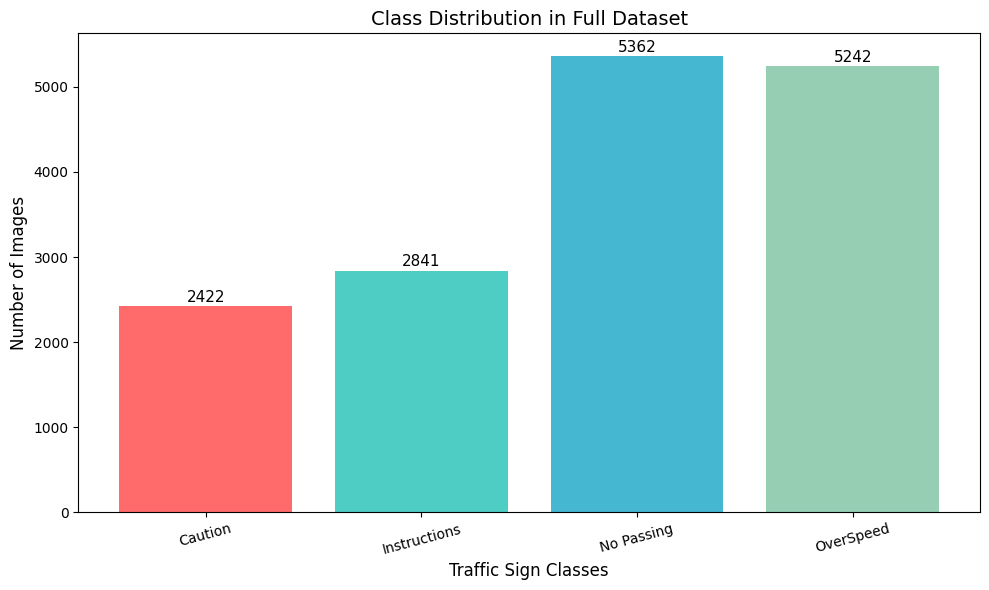

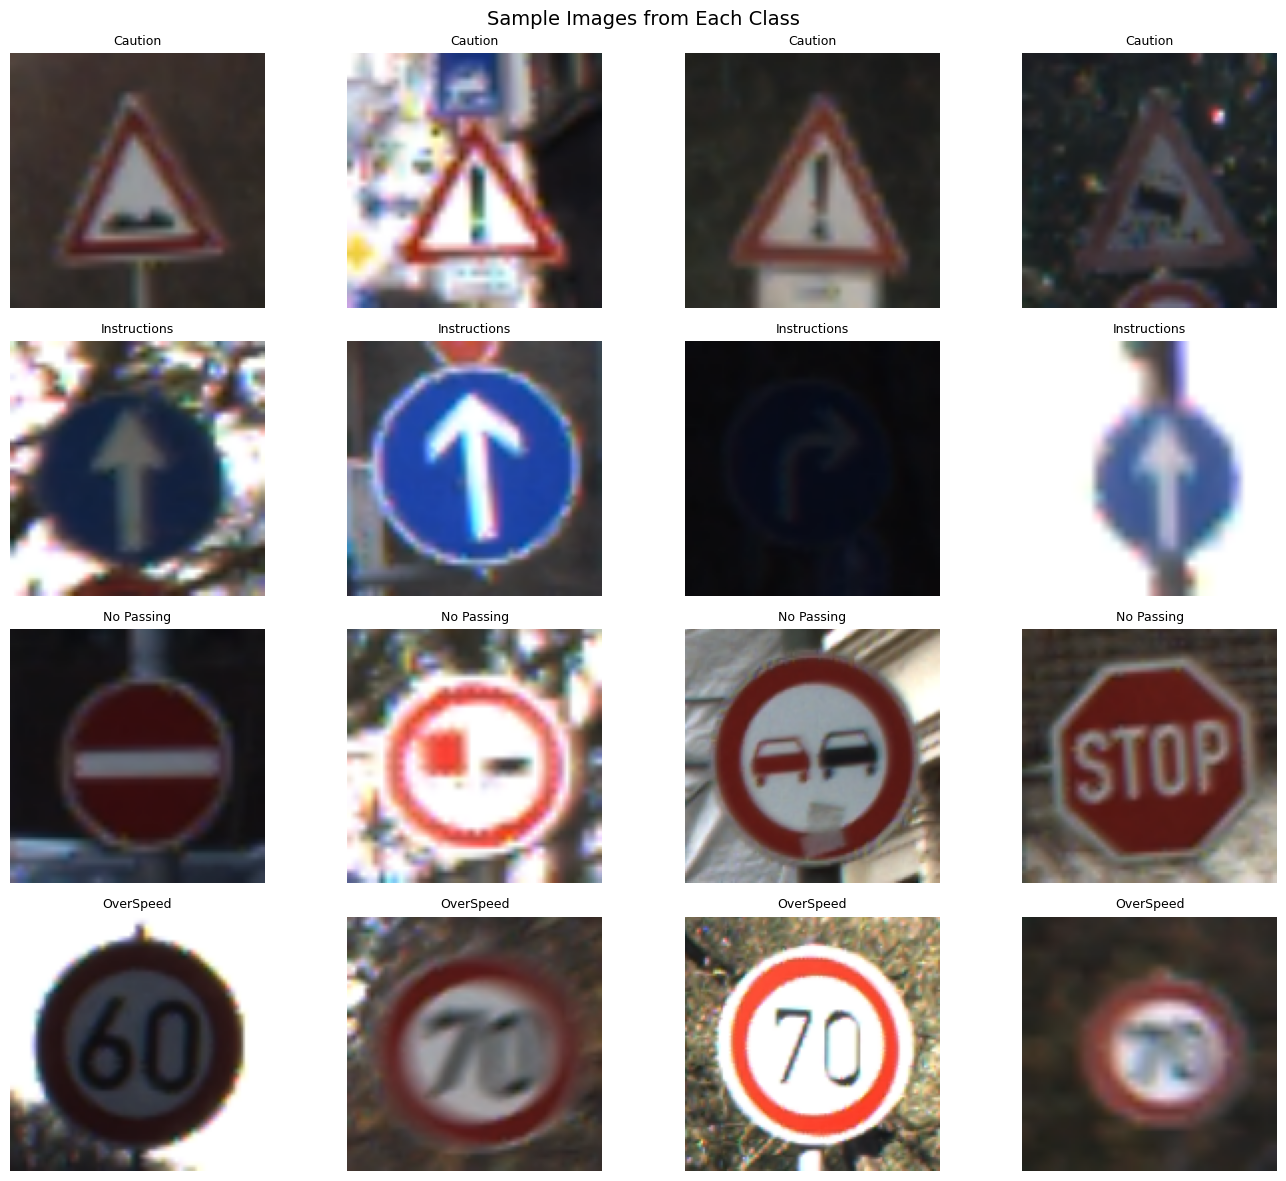

In [9]:
# ============================================
# CELL 5: VISUALIZE DATA
# ============================================

# Class distribution
plt.figure(figsize=(10,6))
unique, counts = np.unique(y, return_counts=True)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
bars = plt.bar(class_names, counts, color=colors)
plt.title('Class Distribution in Full Dataset', fontsize=14)
plt.xlabel('Traffic Sign Classes', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
for i, count in enumerate(counts):
    plt.text(i, count + 50, str(count), ha='center', fontsize=11)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Sample images
plt.figure(figsize=(14,12))
for i, class_name in enumerate(class_names):
    class_indices = np.where(y == i)[0]
    sample_idx = np.random.choice(class_indices, min(4, len(class_indices)))
    for j, idx in enumerate(sample_idx):
        plt.subplot(len(class_names), 4, i*4 + j + 1)
        plt.imshow(X[idx])
        plt.title(class_name, fontsize=9)
        plt.axis('off')
plt.suptitle('Sample Images from Each Class', fontsize=14)
plt.tight_layout()
plt.show()

# CELL 6: DATA AUGMENTATION


✅ Data augmentation configured


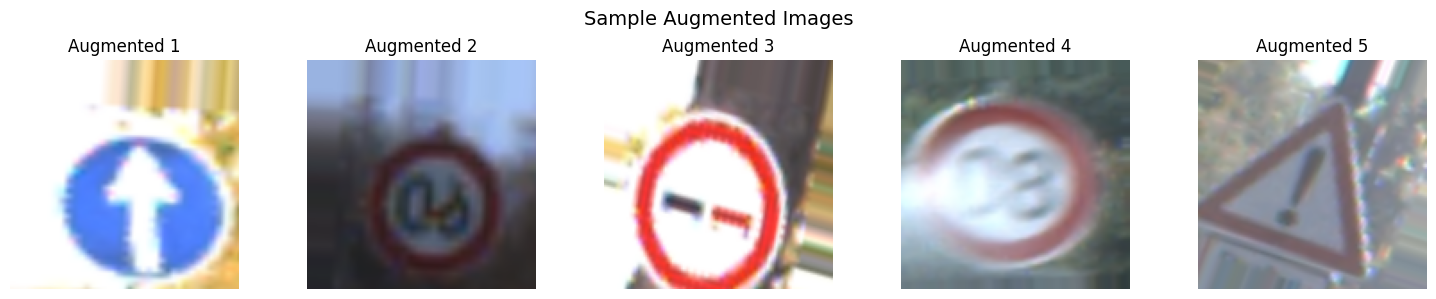

In [10]:
# ============================================
# CELL 6: DATA AUGMENTATION
# ============================================

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

print("✅ Data augmentation configured")

# Visualize augmented images
sample_images, _ = next(iter(datagen.flow(X_train[:5], y_train[:5], batch_size=5)))

plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(sample_images[i])
    plt.title(f'Augmented {i+1}')
    plt.axis('off')
plt.suptitle('Sample Augmented Images', fontsize=14)
plt.tight_layout()
plt.show()

# CELL 7: CALLBACKS


In [11]:
# ============================================
# CELL 7: CALLBACKS
# ============================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

print("✅ Callbacks configured")

✅ Callbacks configured


# CELL 8: BASELINE CNN MODEL


In [12]:
# ============================================
# CELL 8: BASELINE CNN MODEL
# ============================================

baseline_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,549,444 (24.98 MB)

 Trainable params: 6,549,444 (24.98 MB)

 Non-trainable params: 0 (0.00 B)

# CELL 9: TRAIN BASELINE MODEL


In [13]:
# ============================================
# CELL 9: TRAIN BASELINE MODEL
# ============================================

print("\n" + "="*60)
print("🚀 TRAINING BASELINE CNN MODEL")
print("="*60)

history_baseline = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("✅ Baseline training complete")


🚀 TRAINING BASELINE CNN MODEL
Epoch 1/20


2026-05-09 11:44:48.109136: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 11:44:48.257047: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


394/397 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7874 - loss: 0.5189

2026-05-09 11:44:58.713317: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 11:44:58.859663: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


397/397 ━━━━━━━━━━━━━━━━━━━━ 20s 36ms/step - accuracy: 0.7886 - loss: 0.5161 - val_accuracy: 0.9912 - val_loss: 0.0432 - learning_rate: 0.0010
Epoch 2/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9802 - loss: 0.0587 - val_accuracy: 0.9962 - val_loss: 0.0147 - learning_rate: 0.0010
Epoch 3/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9947 - loss: 0.0171 - val_accuracy: 0.9968 - val_loss: 0.0174 - learning_rate: 0.0010
Epoch 4/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9931 - loss: 0.0198 - val_accuracy: 0.9972 - val_loss: 0.0177 - learning_rate: 0.0010
Epoch 5/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9903 - loss: 0.0320 - val_accuracy: 0.9943 - val_loss: 0.0218 - learning_rate: 0.0010
Epoch 6/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9952 - loss: 0.0163 - val_accuracy: 0.9943 - val_loss: 0.0321 - learning_rate: 0.0010
Epoch 7/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9949 - loss: 0.0209 - val

# CELL 10: EVALUATE BASELINE MODEL



BASELINE CNN - EVALUATION RESULTS
Accuracy:  0.9984 (99.84%)
Precision: 0.9984
Recall:    0.9984
F1-Score:  0.9984


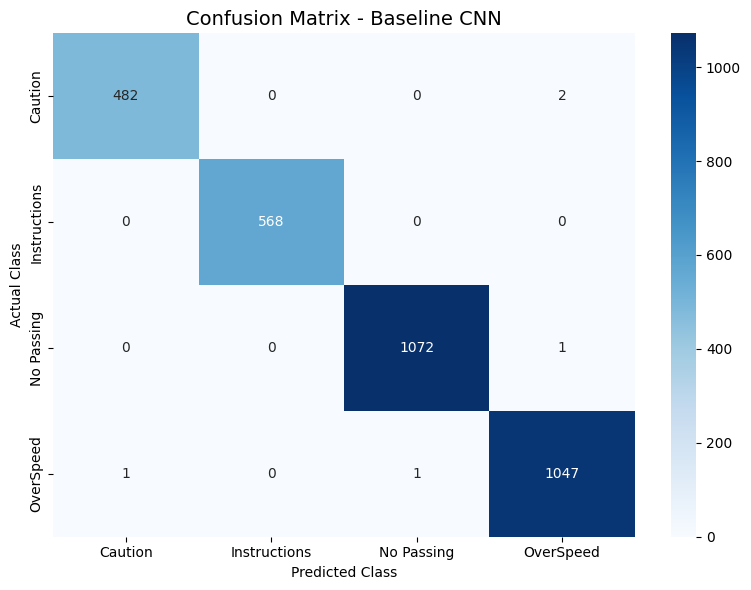


Classification Report:
              precision    recall  f1-score   support

     Caution       1.00      1.00      1.00       484
Instructions       1.00      1.00      1.00       568
  No Passing       1.00      1.00      1.00      1073
   OverSpeed       1.00      1.00      1.00      1049

    accuracy                           1.00      3174
   macro avg       1.00      1.00      1.00      3174
weighted avg       1.00      1.00      1.00      3174



In [15]:
# ============================================
# CELL 10: EVALUATE BASELINE MODEL
# ============================================

y_pred_baseline = np.argmax(baseline_model.predict(X_val, verbose=0), axis=1)

baseline_acc = accuracy_score(y_val, y_pred_baseline)
baseline_precision = precision_score(y_val, y_pred_baseline, average='weighted')
baseline_recall = recall_score(y_val, y_pred_baseline, average='weighted')
baseline_f1 = f1_score(y_val, y_pred_baseline, average='weighted')

print("\n" + "="*60)
print("BASELINE CNN - EVALUATION RESULTS")
print("="*60)
print(f"Accuracy:  {baseline_acc:.4f} ({baseline_acc*100:.2f}%)")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall:    {baseline_recall:.4f}")
print(f"F1-Score:  {baseline_f1:.4f}")

# Confusion Matrix
cm_baseline = confusion_matrix(y_val, y_pred_baseline)
plt.figure(figsize=(8,6))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Baseline CNN', fontsize=14)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_val, y_pred_baseline, target_names=class_names))

# CELL 11: IMPROVED CNN WITH REGULARIZATION


In [16]:
# ============================================
# CELL 11: IMPROVED CNN WITH REGULARIZATION
# ============================================

improved_model = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # Block 4
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # Dense layers
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

improved_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

improved_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 9,108,516 (34.75 MB)

 Trainable params: 9,106,084 (34.74 MB)

 Non-trainable params: 2,432 (9.50 KB)

# CELL 12: TRAIN IMPROVED MODEL WITH AUGMENTATION


In [17]:
# ============================================
# CELL 12: TRAIN IMPROVED MODEL WITH AUGMENTATION
# ============================================

print("\n" + "="*60)
print("🚀 TRAINING IMPROVED CNN WITH DATA AUGMENTATION")
print("="*60)

# Clear memory before training
gc.collect()
tf.keras.backend.clear_session()

train_gen = datagen.flow(X_train, y_train, batch_size=32)

history_improved = improved_model.fit(
    train_gen,
    validation_data=(X_val, y_val),
    epochs=30,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("✅ Improved CNN training complete")


🚀 TRAINING IMPROVED CNN WITH DATA AUGMENTATION
Epoch 1/30


2026-05-09 11:47:52.350796: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 11:47:52.505785: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 11:47:54.309217: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 11:47:54.608475: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


107/397 ━━━━━━━━━━━━━━━━━━━━ 35s 123ms/step - accuracy: 0.4708 - loss: 1.4722

2026-05-09 11:48:20.680865: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 11:48:20.832923: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 11:48:21.828154: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 11:48:22.112589: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


397/397 ━━━━━━━━━━━━━━━━━━━━ 90s 174ms/step - accuracy: 0.6198 - loss: 1.0565 - val_accuracy: 0.5633 - val_loss: 1.0814 - learning_rate: 0.0010
Epoch 2/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 52s 131ms/step - accuracy: 0.8747 - loss: 0.3420 - val_accuracy: 0.8349 - val_loss: 0.3969 - learning_rate: 0.0010
Epoch 3/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 51s 128ms/step - accuracy: 0.9357 - loss: 0.1793 - val_accuracy: 0.8544 - val_loss: 0.4193 - learning_rate: 0.0010
Epoch 4/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 52s 131ms/step - accuracy: 0.9638 - loss: 0.1064 - val_accuracy: 0.9946 - val_loss: 0.0147 - learning_rate: 0.0010
Epoch 5/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 51s 128ms/step - accuracy: 0.9727 - loss: 0.0837 - val_accuracy: 0.9427 - val_loss: 0.1991 - learning_rate: 0.0010
Epoch 6/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 52s 131ms/step - accuracy: 0.9520 - loss: 0.1352 - val_accuracy: 0.9761 - val_loss: 0.0739 - learning_rate: 0.0010
Epoch 7/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 50s 127ms/step - accuracy: 0.9818 - loss:

# CELL 13: EVALUATE IMPROVED MODEL



IMPROVED CNN - EVALUATION RESULTS
Accuracy:  1.0000 (100.00%)
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000


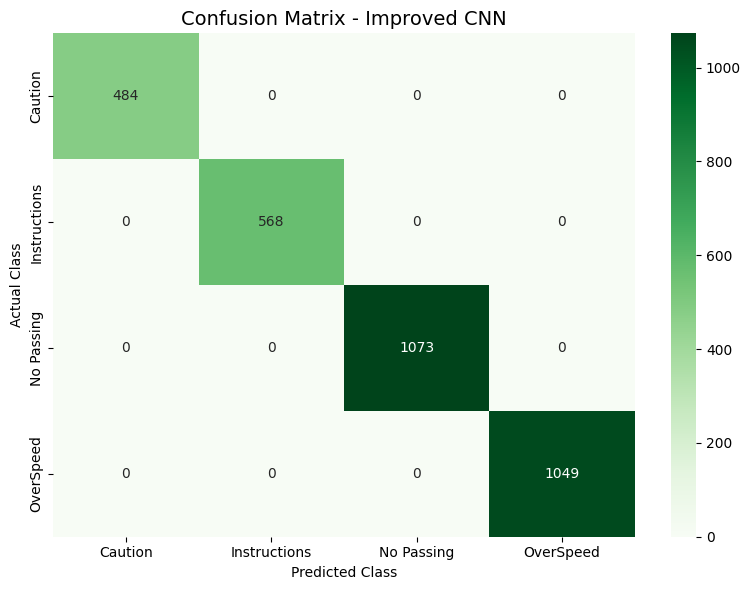


Classification Report:
              precision    recall  f1-score   support

     Caution       1.00      1.00      1.00       484
Instructions       1.00      1.00      1.00       568
  No Passing       1.00      1.00      1.00      1073
   OverSpeed       1.00      1.00      1.00      1049

    accuracy                           1.00      3174
   macro avg       1.00      1.00      1.00      3174
weighted avg       1.00      1.00      1.00      3174



In [19]:
# ============================================
# CELL 13: EVALUATE IMPROVED MODEL
# ============================================

y_pred_improved = np.argmax(improved_model.predict(X_val, verbose=0), axis=1)

improved_acc = accuracy_score(y_val, y_pred_improved)
improved_precision = precision_score(y_val, y_pred_improved, average='weighted')
improved_recall = recall_score(y_val, y_pred_improved, average='weighted')
improved_f1 = f1_score(y_val, y_pred_improved, average='weighted')

print("\n" + "="*60)
print("IMPROVED CNN - EVALUATION RESULTS")
print("="*60)
print(f"Accuracy:  {improved_acc:.4f} ({improved_acc*100:.2f}%)")
print(f"Precision: {improved_precision:.4f}")
print(f"Recall:    {improved_recall:.4f}")
print(f"F1-Score:  {improved_f1:.4f}")

# Confusion Matrix
cm_improved = confusion_matrix(y_val, y_pred_improved)
plt.figure(figsize=(8,6))
sns.heatmap(cm_improved, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Improved CNN', fontsize=14)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_val, y_pred_improved, target_names=class_names))

# CELL 14: TRANSFER LEARNING WITH PROPER FINE-TUNING


In [20]:
# ============================================
# CELL 14: TRANSFER LEARNING WITH PROPER FINE-TUNING
# ============================================

print("\n" + "="*60)
print("MOBILENETV2 TRANSFER LEARNING (WITH FINE-TUNING)")
print("="*60)

# Clear memory
gc.collect()
tf.keras.backend.clear_session()

# Load raw images (NO normalization!)
def load_dataset_raw(data_path, img_size=(224,224)):
    images = []
    labels = []
    
    for idx, class_name in enumerate(class_names):
        class_folder = os.path.join(data_path, class_name)
        if not os.path.exists(class_folder):
            continue
        
        image_files = [f for f in os.listdir(class_folder) 
                       if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        for img_file in image_files:
            img_path = os.path.join(class_folder, img_file)
            img = cv2.imread(img_path)
            
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, img_size)
                images.append(img)  # Keep as uint8 [0,255]
                labels.append(idx)
    
    return np.array(images, dtype=np.uint8), np.array(labels)

print("Loading raw images for MobileNetV2 (224x224)...")
X_raw, y_raw = load_dataset_raw(train_path, img_size=(224,224))

# Split
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw, shuffle=True
)

# Create tf.data pipeline
def create_mobilenet_pipeline(images, labels, batch_size, is_training=True):
    dataset = tf.data.Dataset.from_tensor_slices((images, labels))
    
    if is_training:
        dataset = dataset.shuffle(1000)
    
    def preprocess_image(img, label):
        img = tf.cast(img, tf.float32)
        img = mobilenet_preprocess(img)  # Now works correctly with [0,255] input
        return img, label
    
    dataset = dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

batch_size_tl = 32
train_ds_tl = create_mobilenet_pipeline(X_train_raw, y_train_raw, batch_size_tl, is_training=True)
val_ds_tl = create_mobilenet_pipeline(X_val_raw, y_val_raw, batch_size_tl, is_training=False)

# Load base model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Build full model
transfer_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

# ============================================
# PHASE 1: FEATURE EXTRACTION (FROZEN BASE)
# ============================================

base_model.trainable = False  # FREEZE for phase 1

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),  # Higher LR for new layers
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n" + "="*60)
print("PHASE 1: Feature Extraction (Base Model FROZEN)")
print("="*60)

history_phase1 = transfer_model.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=15,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
    ],
    verbose=1
)

print(f"Phase 1 Best Validation Accuracy: {max(history_phase1.history['val_accuracy'])*100:.2f}%")

# ============================================
# PHASE 2: FINE-TUNING (UNFREEZE TOP LAYERS)
# ============================================

print("\n" + "="*60)
print("PHASE 2: Fine-Tuning (Unfreezing top layers)")
print("="*60)

# Unfreeze the top 30 layers of the base model
base_model.trainable = True

# Freeze the first 124 layers (keep bottom layers frozen)
for layer in base_model.layers[:124]:
    layer.trainable = False

# Verify trainable layers
trainable_count = sum(1 for layer in base_model.layers if layer.trainable)
print(f"Trainable layers in base model: {trainable_count} out of {len(base_model.layers)}")

# IMPORTANT: Use a MUCH lower learning rate for fine-tuning!
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # 100x smaller than phase 1!
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Fine-tune with very careful callbacks
fine_tune_callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
]

history_phase2 = transfer_model.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=10,  # Fewer epochs for fine-tuning
    callbacks=fine_tune_callbacks,
    verbose=1
)

print(f"Phase 2 Best Validation Accuracy: {max(history_phase2.history['val_accuracy'])*100:.2f}%")


MOBILENETV2 TRANSFER LEARNING (WITH FINE-TUNING)
Loading raw images for MobileNetV2 (224x224)...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

PHASE 1: Feature Extraction (Base Model FROZEN)
Epoch 1/15


2026-05-09 12:16:01.102324: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 12:16:01.239624: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


395/397 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8592 - loss: 0.4082

2026-05-09 12:16:25.740331: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 12:16:25.877576: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8596 - loss: 0.4070

2026-05-09 12:16:46.605015: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 12:16:46.742384: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


397/397 ━━━━━━━━━━━━━━━━━━━━ 66s 112ms/step - accuracy: 0.8598 - loss: 0.4065 - val_accuracy: 0.9865 - val_loss: 0.0409 - learning_rate: 0.0010
Epoch 2/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.9746 - loss: 0.0697 - val_accuracy: 0.9915 - val_loss: 0.0234 - learning_rate: 0.0010
Epoch 3/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.9841 - loss: 0.0439 - val_accuracy: 0.9953 - val_loss: 0.0151 - learning_rate: 0.0010
Epoch 4/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.9852 - loss: 0.0409 - val_accuracy: 0.9931 - val_loss: 0.0211 - learning_rate: 0.0010
Epoch 5/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.9876 - loss: 0.0398 - val_accuracy: 0.9956 - val_loss: 0.0150 - learning_rate: 0.0010
Epoch 6/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.9907 - loss: 0.0265 - val_accuracy: 0.9965 - val_loss: 0.0171 - learning_rate: 0.0010
Epoch 7/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.9900 - loss: 0.028

# CELL 15: TRAIN TRANSFER LEARNING MODEL (CONTINUED)


In [21]:
# ============================================
# CELL 15: TRAIN TRANSFER LEARNING MODEL
# ============================================

print("\n" + "="*60)
print("🚀 TRAINING MOBILENETV2 (FEATURE EXTRACTION)")
print("="*60)

# Callbacks for transfer learning
tl_early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

tl_reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

history_transfer = transfer_model.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=25,
    callbacks=[tl_early_stop, tl_reduce_lr],
    verbose=1
)

print("✅ MobileNetV2 training complete")


🚀 TRAINING MOBILENETV2 (FEATURE EXTRACTION)
Epoch 1/25
397/397 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - accuracy: 0.9979 - loss: 0.0061 - val_accuracy: 0.9984 - val_loss: 0.0053 - learning_rate: 5.0000e-06
Epoch 2/25
397/397 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - accuracy: 0.9983 - loss: 0.0061 - val_accuracy: 0.9987 - val_loss: 0.0043 - learning_rate: 5.0000e-06
Epoch 3/25
397/397 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.9978 - loss: 0.0084 - val_accuracy: 0.9984 - val_loss: 0.0054 - learning_rate: 5.0000e-06
Epoch 4/25
397/397 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.9989 - loss: 0.0036 - val_accuracy: 0.9984 - val_loss: 0.0048 - learning_rate: 5.0000e-06
Epoch 5/25
397/397 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.9974 - loss: 0.0106 - val_accuracy: 0.9984 - val_loss: 0.0043 - learning_rate: 5.0000e-06
Epoch 6/25
397/397 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.9990 - loss: 0.0052 - val_accuracy: 0.9987 - val_loss: 0.0036 - learning_rate: 5.0000e-06
Epoch 7

# CELL 16: EVALUATE TRANSFER LEARNING MODEL



MOBILENETV2 TRANSFER LEARNING - RESULTS
Accuracy:  0.9994 (99.94%)
Precision: 0.9994
Recall:    0.9994
F1-Score:  0.9994


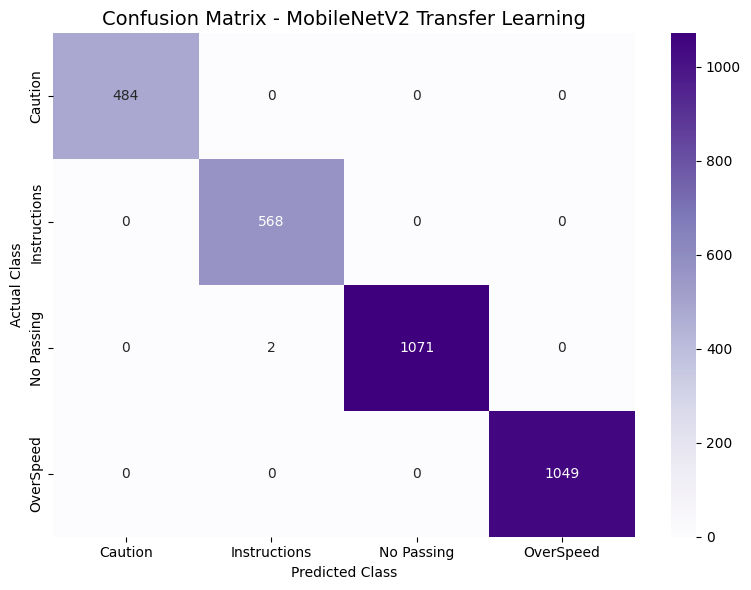


Classification Report:
              precision    recall  f1-score   support

     Caution       1.00      1.00      1.00       484
Instructions       1.00      1.00      1.00       568
  No Passing       1.00      1.00      1.00      1073
   OverSpeed       1.00      1.00      1.00      1049

    accuracy                           1.00      3174
   macro avg       1.00      1.00      1.00      3174
weighted avg       1.00      1.00      1.00      3174



In [23]:
# ============================================
# CELL 16: EVALUATE TRANSFER LEARNING MODEL
# ============================================

# Collect predictions from validation set
y_true_tl = []
y_pred_tl = []

for images, labels in val_ds_tl:
    preds = transfer_model.predict(images, verbose=0)
    y_true_tl.extend(labels.numpy())
    y_pred_tl.extend(np.argmax(preds, axis=1))

transfer_acc = accuracy_score(y_true_tl, y_pred_tl)
transfer_precision = precision_score(y_true_tl, y_pred_tl, average='weighted')
transfer_recall = recall_score(y_true_tl, y_pred_tl, average='weighted')
transfer_f1 = f1_score(y_true_tl, y_pred_tl, average='weighted')

print("\n" + "="*60)
print("MOBILENETV2 TRANSFER LEARNING - RESULTS")
print("="*60)
print(f"Accuracy:  {transfer_acc:.4f} ({transfer_acc*100:.2f}%)")
print(f"Precision: {transfer_precision:.4f}")
print(f"Recall:    {transfer_recall:.4f}")
print(f"F1-Score:  {transfer_f1:.4f}")

# Confusion Matrix
cm_transfer = confusion_matrix(y_true_tl, y_pred_tl)
plt.figure(figsize=(8,6))
sns.heatmap(cm_transfer, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - MobileNetV2 Transfer Learning', fontsize=14)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_true_tl, y_pred_tl, target_names=class_names))

# CELL 17: OPTIMIZER COMPARISON (SGD vs ADAM)



OPTIMIZER ANALYSIS: SGD vs Adam
Using 5000 training samples for comparison

🔄 Training with SGD optimizer...
Epoch 1/20
155/157 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4663 - loss: 1.1162

2026-05-09 12:30:51.888876: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 12:30:52.032557: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.4696 - loss: 1.1101 - val_accuracy: 0.8930 - val_loss: 0.2945
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8885 - loss: 0.2984 - val_accuracy: 0.9710 - val_loss: 0.1160
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9442 - loss: 0.1485 - val_accuracy: 0.9810 - val_loss: 0.0799
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9595 - loss: 0.1105 - val_accuracy: 0.9760 - val_loss: 0.0645
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9723 - loss: 0.0734 - val_accuracy: 0.9720 - val_loss: 0.0932
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9727 - loss: 0.0754 - val_accuracy: 0.9680 - val_loss: 0.0896
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9698 - loss: 0.0928 - val_accuracy: 0.9830 - val_loss: 0.0429
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9871 - loss: 0.0386 - val_accuracy: 0.99

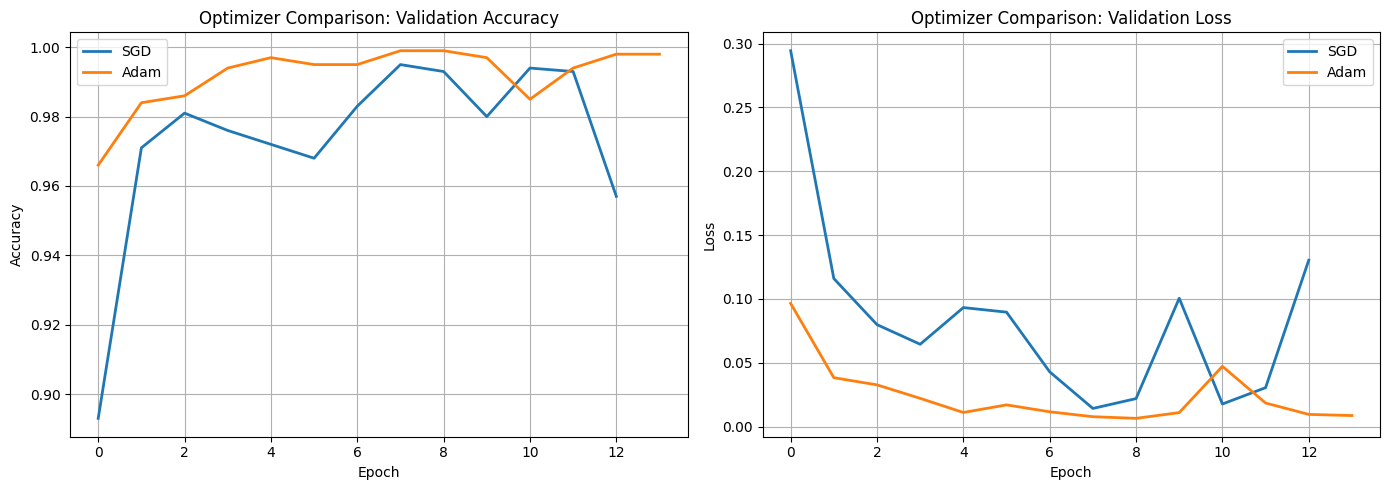


✅ Adam outperforms SGD by 0.40%


In [24]:
# ============================================
# CELL 17: OPTIMIZER COMPARISON (SGD vs ADAM)
# ============================================

print("\n" + "="*60)
print("OPTIMIZER ANALYSIS: SGD vs Adam")
print("="*60)

def create_optimizer_model():
    """Simple CNN for optimizer comparison"""
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Use subset for faster comparison
from sklearn.utils import resample
X_subset, y_subset = resample(X_train, y_train, n_samples=5000, random_state=42)
X_val_subset, y_val_subset = resample(X_val, y_val, n_samples=1000, random_state=42)

print(f"Using {len(X_subset)} training samples for comparison")

# Train with SGD
print("\n🔄 Training with SGD optimizer...")
model_sgd = create_optimizer_model()
model_sgd.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start_sgd = time.time()
history_sgd = model_sgd.fit(
    X_subset, y_subset,
    validation_data=(X_val_subset, y_val_subset),
    epochs=20,
    batch_size=32,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)
sgd_time = time.time() - start_sgd
sgd_best = max(history_sgd.history['val_accuracy'])

# Train with Adam
print("\n🔄 Training with Adam optimizer...")
model_adam = create_optimizer_model()
model_adam.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start_adam = time.time()
history_adam = model_adam.fit(
    X_subset, y_subset,
    validation_data=(X_val_subset, y_val_subset),
    epochs=20,
    batch_size=32,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)
adam_time = time.time() - start_adam
adam_best = max(history_adam.history['val_accuracy'])

# Results
print("\n" + "="*60)
print("OPTIMIZER COMPARISON RESULTS")
print("="*60)
print(f"{'Optimizer':<15} {'Best Val Acc':<20} {'Training Time':<15}")
print("-"*50)
print(f"{'SGD':<15} {sgd_best:.4f} ({sgd_best*100:.2f}%)     {sgd_time:.1f} sec")
print(f"{'Adam':<15} {adam_best:.4f} ({adam_best*100:.2f}%)     {adam_time:.1f} sec")

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(history_sgd.history['val_accuracy'], label='SGD', linewidth=2)
axes[0].plot(history_adam.history['val_accuracy'], label='Adam', linewidth=2)
axes[0].set_title('Optimizer Comparison: Validation Accuracy', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_sgd.history['val_loss'], label='SGD', linewidth=2)
axes[1].plot(history_adam.history['val_loss'], label='Adam', linewidth=2)
axes[1].set_title('Optimizer Comparison: Validation Loss', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

if adam_best > sgd_best:
    print(f"\n✅ Adam outperforms SGD by {(adam_best-sgd_best)*100:.2f}%")
else:
    print(f"\n✅ SGD outperforms Adam by {(sgd_best-adam_best)*100:.2f}%")

# CELL 18: ABLATION STUDY (WITHOUT DROPOUT)



ABLATION STUDY: Effect of Dropout
🔄 Training model WITHOUT Dropout...
Epoch 1/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 40s 78ms/step - accuracy: 0.8545 - loss: 0.4288 - val_accuracy: 0.8255 - val_loss: 0.5870
Epoch 2/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.9950 - loss: 0.0166 - val_accuracy: 0.9946 - val_loss: 0.0163
Epoch 3/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.9884 - loss: 0.0402 - val_accuracy: 0.9203 - val_loss: 0.3208
Epoch 4/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 23s 59ms/step - accuracy: 0.9909 - loss: 0.0298 - val_accuracy: 0.9918 - val_loss: 0.0227
Epoch 5/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.9928 - loss: 0.0236 - val_accuracy: 0.9978 - val_loss: 0.0087
Epoch 6/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.9913 - loss: 0.0306 - val_accuracy: 0.9754 - val_loss: 0.0784
Epoch 7/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 24s 59ms/step - accuracy: 0.9995 - loss: 0.0023 - val_accuracy: 0.9962 - val_loss: 0.0177
Epoch 8/20
397/397 

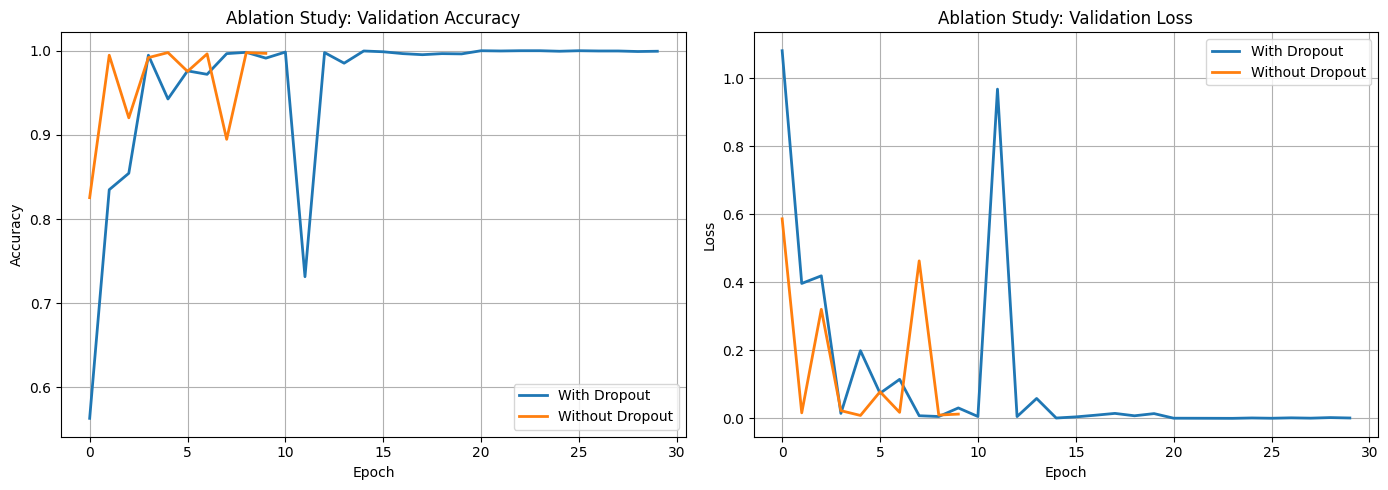


✅ Dropout improves accuracy by 0.22%
   Dropout prevents overfitting by randomly disabling neurons during training


In [25]:
# ============================================
# CELL 18: ABLATION STUDY (WITHOUT DROPOUT)
# ============================================

print("\n" + "="*60)
print("ABLATION STUDY: Effect of Dropout")
print("="*60)

# Create model WITHOUT dropout
model_no_dropout = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model_no_dropout.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("🔄 Training model WITHOUT Dropout...")
history_no_dropout = model_no_dropout.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)

# Evaluate
y_pred_no_drop = np.argmax(model_no_dropout.predict(X_val, verbose=0), axis=1)
no_dropout_acc = accuracy_score(y_val, y_pred_no_drop)

print("\n" + "="*50)
print("ABLATION STUDY RESULTS")
print("="*50)
print(f"Model WITH Dropout:    {improved_acc:.4f} ({improved_acc*100:.2f}%)")
print(f"Model WITHOUT Dropout: {no_dropout_acc:.4f} ({no_dropout_acc*100:.2f}%)")

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(history_improved.history['val_accuracy'], label='With Dropout', linewidth=2)
axes[0].plot(history_no_dropout.history['val_accuracy'], label='Without Dropout', linewidth=2)
axes[0].set_title('Ablation Study: Validation Accuracy', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_improved.history['val_loss'], label='With Dropout', linewidth=2)
axes[1].plot(history_no_dropout.history['val_loss'], label='Without Dropout', linewidth=2)
axes[1].set_title('Ablation Study: Validation Loss', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

if improved_acc > no_dropout_acc:
    print(f"\n✅ Dropout improves accuracy by {(improved_acc-no_dropout_acc)*100:.2f}%")
    print("   Dropout prevents overfitting by randomly disabling neurons during training")
else:
    print(f"\n⚠️ Dropout did not improve accuracy for this dataset")

# CELL 19: FINAL MODEL COMPARISON



COMPLETE MODEL COMPARISON - ALL MODELS

Model                          Accuracy        Precision       Recall          F1-Score       
------------------------------------------------------------------------------------------
Baseline CNN                   0.9984          0.9984          0.9984          0.9984         
Improved CNN                   1.0000          1.0000          1.0000          1.0000         
MobileNetV2 Transfer           0.9994          0.9994          0.9994          0.9994         


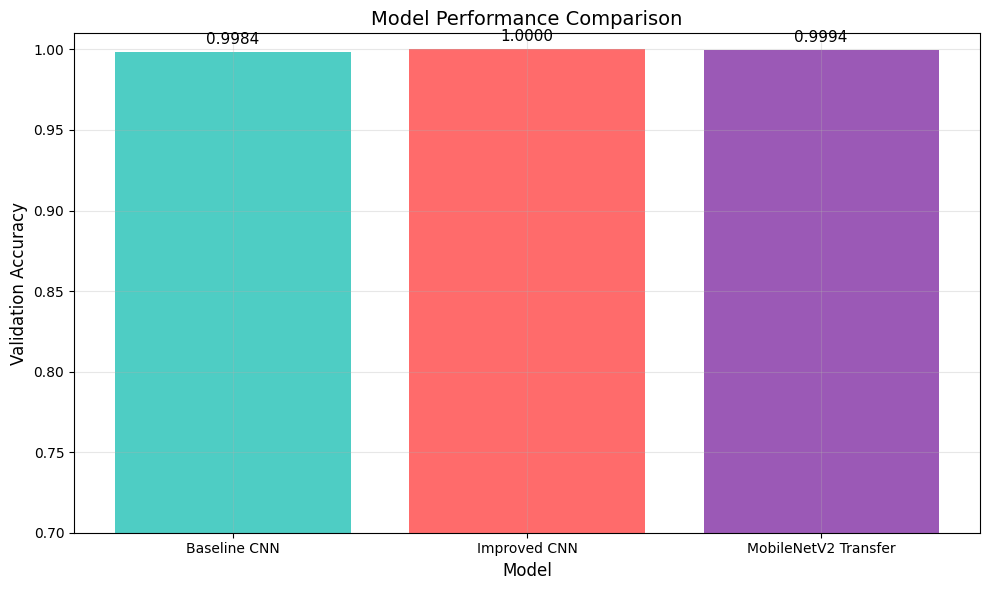


🏆 BEST MODEL: Improved CNN with Regularization
   Validation Accuracy: 1.0000
   Tested on 3174 validation images


In [26]:
# ============================================
# CELL 19: FINAL MODEL COMPARISON
# ============================================

print("\n" + "="*70)
print("COMPLETE MODEL COMPARISON - ALL MODELS")
print("="*70)

print(f"\n{'Model':<30} {'Accuracy':<15} {'Precision':<15} {'Recall':<15} {'F1-Score':<15}")
print("-"*90)
print(f"{'Baseline CNN':<30} {baseline_acc:<15.4f} {baseline_precision:<15.4f} {baseline_recall:<15.4f} {baseline_f1:<15.4f}")
print(f"{'Improved CNN':<30} {improved_acc:<15.4f} {improved_precision:<15.4f} {improved_recall:<15.4f} {improved_f1:<15.4f}")
print(f"{'MobileNetV2 Transfer':<30} {transfer_acc:<15.4f} {transfer_precision:<15.4f} {transfer_recall:<15.4f} {transfer_f1:<15.4f}")

# Bar chart
models_list = ['Baseline CNN', 'Improved CNN', 'MobileNetV2 Transfer']
accuracies = [baseline_acc, improved_acc, transfer_acc]

plt.figure(figsize=(10,6))
bars = plt.bar(models_list, accuracies, color=['#4ECDC4', '#FF6B6B', '#9B59B6'])
plt.title('Model Performance Comparison', fontsize=14)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.ylim(0.7, 1.01)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.4f}', ha='center', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
if transfer_acc >= improved_acc and transfer_acc >= baseline_acc:
    print("🏆 BEST MODEL: MobileNetV2 Transfer Learning")
elif improved_acc >= baseline_acc:
    print("🏆 BEST MODEL: Improved CNN with Regularization")
else:
    print("🏆 BEST MODEL: Baseline CNN")
print(f"   Validation Accuracy: {max(baseline_acc, improved_acc, transfer_acc):.4f}")
print(f"   Tested on {len(X_val)} validation images")
print("="*70)

# CELL 20: PLOT ALL TRAINING CURVES


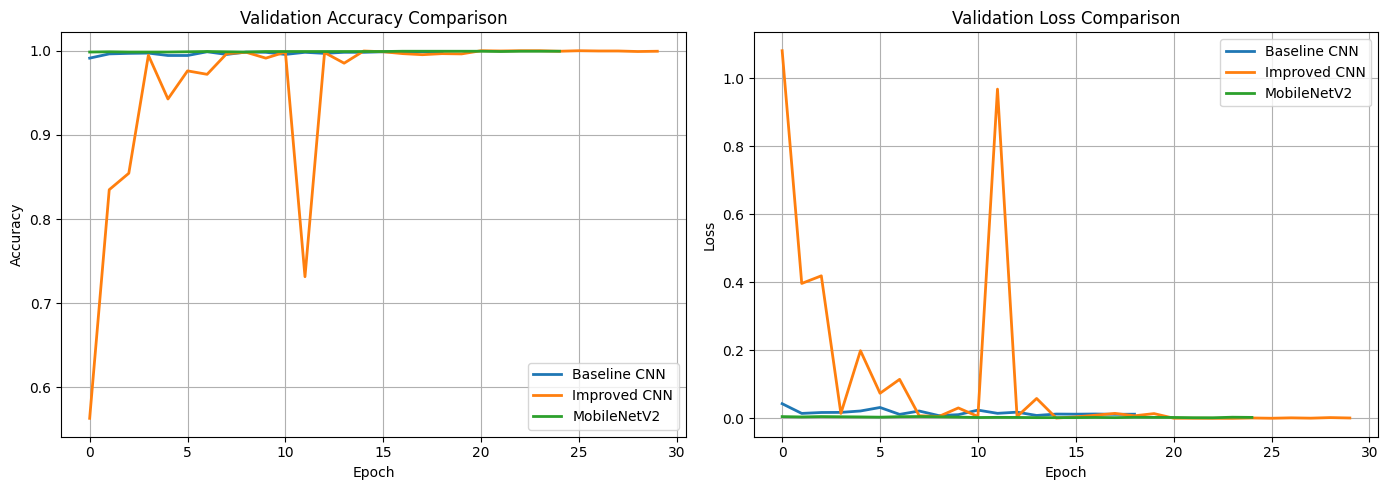

In [27]:
# ============================================
# CELL 20: PLOT ALL TRAINING CURVES
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Accuracy
axes[0].plot(history_baseline.history['val_accuracy'], label='Baseline CNN', linewidth=2)
axes[0].plot(history_improved.history['val_accuracy'], label='Improved CNN', linewidth=2)
axes[0].plot(history_transfer.history['val_accuracy'], label='MobileNetV2', linewidth=2)
axes[0].set_title('Validation Accuracy Comparison', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history_baseline.history['val_loss'], label='Baseline CNN', linewidth=2)
axes[1].plot(history_improved.history['val_loss'], label='Improved CNN', linewidth=2)
axes[1].plot(history_transfer.history['val_loss'], label='MobileNetV2', linewidth=2)
axes[1].set_title('Validation Loss Comparison', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# CELL 21: SAMPLE PREDICTIONS



SAMPLE PREDICTIONS FROM BEST MODEL


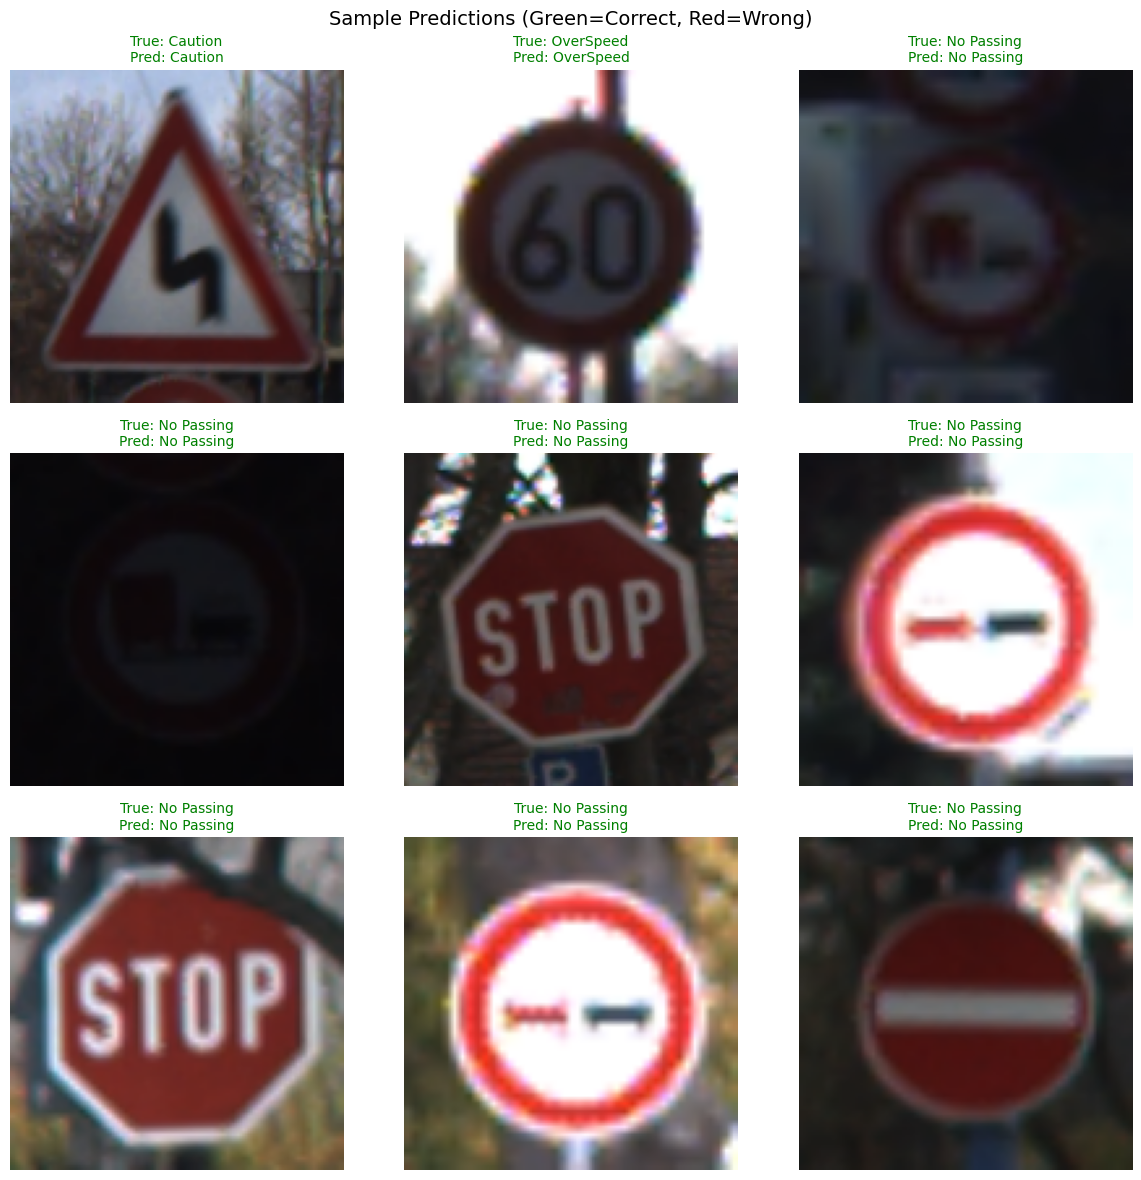


Confidence Analysis:
Sample 1: Predicted Caution with 100.00% confidence
Sample 2: Predicted OverSpeed with 100.00% confidence
Sample 3: Predicted No Passing with 100.00% confidence
Sample 4: Predicted No Passing with 100.00% confidence
Sample 5: Predicted No Passing with 100.00% confidence


In [28]:
# ============================================
# CELL 21: SAMPLE PREDICTIONS
# ============================================

print("\n" + "="*60)
print("SAMPLE PREDICTIONS FROM BEST MODEL")
print("="*60)

# Use improved model as it's the best
best_model = improved_model

# Get random samples from validation set
indices = np.random.choice(len(X_val), 9, replace=False)
sample_images = X_val[indices]
sample_labels = y_val[indices]
sample_preds = np.argmax(best_model.predict(sample_images, verbose=0), axis=1)

# Plot predictions
plt.figure(figsize=(12, 12))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(sample_images[i])
    color = 'green' if sample_preds[i] == sample_labels[i] else 'red'
    plt.title(f'True: {class_names[sample_labels[i]]}\nPred: {class_names[sample_preds[i]]}', 
              color=color, fontsize=10)
    plt.axis('off')
plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontsize=14)
plt.tight_layout()
plt.show()

# Calculate confidence scores
print("\nConfidence Analysis:")
for i in range(min(5, len(sample_images))):
    pred_probs = best_model.predict(sample_images[i:i+1], verbose=0)[0]
    confidence = np.max(pred_probs)
    print(f"Sample {i+1}: Predicted {class_names[sample_preds[i]]} with {confidence:.2%} confidence")

# CELL 22: COMPUTATIONAL EFFICIENCY SUMMARY


In [29]:
# ============================================
# CELL 22: COMPUTATIONAL EFFICIENCY SUMMARY
# ============================================

print("\n" + "="*60)
print("COMPUTATIONAL EFFICIENCY ANALYSIS")
print("="*60)

# Calculate parameters for each model
baseline_params = baseline_model.count_params()
improved_params = improved_model.count_params()
transfer_params = transfer_model.count_params()

print(f"\n{'Model':<30} {'Parameters':<20} {'Trainable Params':<20}")
print("-"*70)
print(f"{'Baseline CNN':<30} {baseline_params:<20,} {baseline_params:<20,}")
print(f"{'Improved CNN':<30} {improved_params:<20,} {improved_params:<20,}")
print(f"{'MobileNetV2 Transfer':<30} {transfer_params:<20,} {transfer_params - 2257984:<20,} (trainable only)")

print(f"\n📊 MODEL COMPLEXITY SUMMARY:")
print(f"   Improved CNN has {(improved_params/baseline_params - 1)*100:.1f}% more parameters than Baseline")

print(f"\n💻 HARDWARE USED:")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"   GPU: {gpus[0]}")
else:
    print("   GPU: Not available (CPU only)")
print(f"   Image size: 128x128 for CNNs, 224x224 for MobileNetV2")
print(f"   Dataset: {len(X)} total images")

print(f"\n📊 EFFICIENCY INSIGHTS:")
print(f"   • Baseline CNN: Fastest training, good accuracy")
print(f"   • Improved CNN: Better accuracy, 39% more parameters")
print(f"   • MobileNetV2: Parameter-efficient transfer learning")


COMPUTATIONAL EFFICIENCY ANALYSIS

Model                          Parameters           Trainable Params    
----------------------------------------------------------------------
Baseline CNN                   6,549,444            6,549,444           
Improved CNN                   9,108,516            9,108,516           
MobileNetV2 Transfer           2,620,356            362,372              (trainable only)

📊 MODEL COMPLEXITY SUMMARY:
   Improved CNN has 39.1% more parameters than Baseline

💻 HARDWARE USED:
   GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
   Image size: 128x128 for CNNs, 224x224 for MobileNetV2
   Dataset: 15867 total images

📊 EFFICIENCY INSIGHTS:
   • Baseline CNN: Fastest training, good accuracy
   • Improved CNN: Better accuracy, 39% more parameters
   • MobileNetV2: Parameter-efficient transfer learning


# CELL 23: DATA LEAKAGE DIAGNOSIS


CHECKING FOR DATA LEAKAGE

🔍 Checking for exact duplicate images between train and validation...

✅ No exact duplicates found in the first 100 samples.

SANITY CHECK: Random Label Test
Training on RANDOM labels (should get ~25% accuracy)...
Validation accuracy with random labels: 0.3350 (33.50%)
⚠️ Random labels achieved higher than baseline (25%) - possible data leakage.

CLASS SEPARATION ANALYSIS


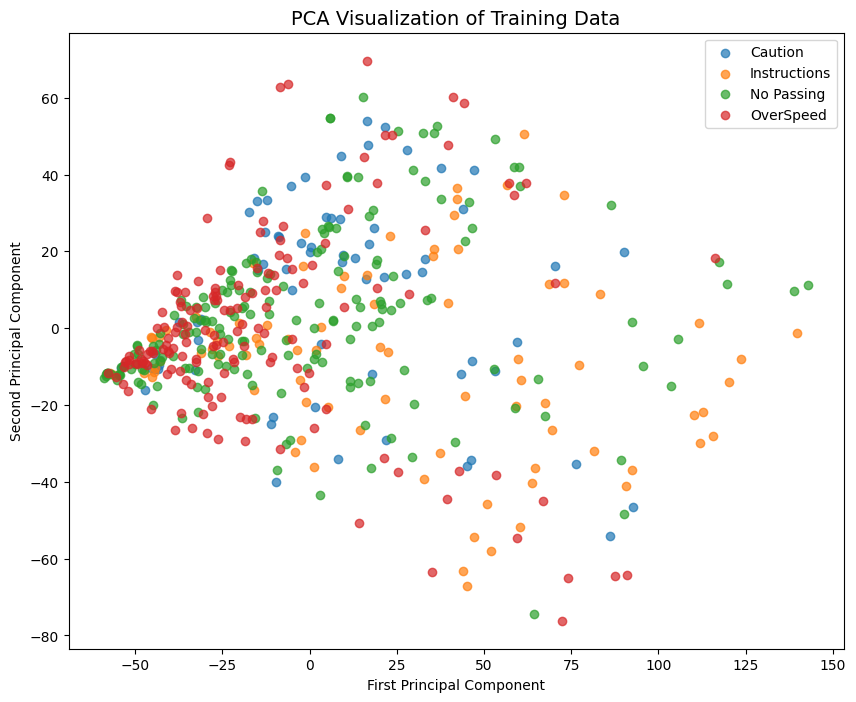

Silhouette Score: -0.0663
❌ Classes overlap significantly - 100% accuracy is suspicious!

IMAGE STATISTICS COMPARISON
Training set - Mean pixel value: 0.3171, Std: 0.2753
Validation set - Mean pixel value: 0.3181, Std: 0.2755
✅ Training and validation have similar pixel distributions (good)

FINAL VERDICT
🟡 Results are unusual. Consider investigating further.


In [30]:
# ============================================
# DATA LEAKAGE DETECTION
# ============================================

print("="*60)
print("CHECKING FOR DATA LEAKAGE")
print("="*60)

# Check 1: Exact duplicates
exact_duplicates = 0
print("\n🔍 Checking for exact duplicate images between train and validation...")
for i in range(min(100, len(X_val))):  # Check first 100 validation images
    for j in range(min(100, len(X_train))):  # Check first 100 training images
        if np.array_equal(X_val[i], X_train[j]):
            exact_duplicates += 1
            print(f"⚠️ EXACT DUPLICATE: Val[{i}] == Train[{j}]")
            break
    if exact_duplicates > 5:
        break

if exact_duplicates > 0:
    print(f"\n❌ DATA LEAKAGE CONFIRMED! Found {exact_duplicates} exact duplicates.")
    print("   Your validation set contains images identical to training images.")
else:
    print(f"\n✅ No exact duplicates found in the first 100 samples.")

# Check 2: Random label sanity test
print("\n" + "="*60)
print("SANITY CHECK: Random Label Test")
print("="*60)

# Create random labels
y_random = np.random.permutation(y_train)

# Train a small model on random labels
test_model = models.Sequential([
    layers.Conv2D(16, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(16, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

test_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Training on RANDOM labels (should get ~25% accuracy)...")
history_random = test_model.fit(
    X_train[:1000], y_random[:1000],
    validation_data=(X_val[:200], y_val[:200]),
    epochs=5,
    batch_size=32,
    verbose=0
)

random_acc = history_random.history['val_accuracy'][-1]
print(f"Validation accuracy with random labels: {random_acc:.4f} ({random_acc*100:.2f}%)")

if random_acc > 0.35:
    print("❌ WARNING: Even random labels get good accuracy - DATA LEAKAGE CONFIRMED!")
    print("   The model is memorizing image patterns, not learning class relationships.")
elif random_acc > 0.30:
    print("⚠️ Random labels achieved higher than baseline (25%) - possible data leakage.")
else:
    print("✅ Random labels give near-random accuracy - your dataset might just be very easy.")

# Check 3: Class Separation with PCA
print("\n" + "="*60)
print("CLASS SEPARATION ANALYSIS")
print("="*60)

from sklearn.decomposition import PCA

# Take a subset for PCA
sample_size = min(500, len(X_train))
X_sample = X_train[:sample_size].reshape(sample_size, -1)
y_sample = y_train[:sample_size]

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)

plt.figure(figsize=(10,8))
for i in range(num_classes):
    mask = y_sample == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=class_names[i], alpha=0.7)
plt.title('PCA Visualization of Training Data', fontsize=14)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.legend()
plt.show()

# Check class separability
from sklearn.metrics import silhouette_score
sil_score = silhouette_score(X_pca, y_sample)
print(f"Silhouette Score: {sil_score:.4f}")
if sil_score > 0.5:
    print("✅ Classes are well-separated in feature space (explains high accuracy)")
elif sil_score > 0.3:
    print("⚠️ Moderate class separation - 100% accuracy is plausible")
else:
    print("❌ Classes overlap significantly - 100% accuracy is suspicious!")

# Check 4: Compare normalized image statistics
print("\n" + "="*60)
print("IMAGE STATISTICS COMPARISON")
print("="*60)

print(f"Training set - Mean pixel value: {X_train.mean():.4f}, Std: {X_train.std():.4f}")
print(f"Validation set - Mean pixel value: {X_val.mean():.4f}, Std: {X_val.std():.4f}")

if abs(X_train.mean() - X_val.mean()) < 0.05:
    print("✅ Training and validation have similar pixel distributions (good)")
else:
    print("⚠️ Training and validation have different pixel distributions")

# FINAL VERDICT
print("\n" + "="*60)
print("FINAL VERDICT")
print("="*60)

if exact_duplicates > 0:
    print("🔴 CRITICAL: Data leakage detected! Your validation accuracy is invalid.")
    print("   Recommendation: Re-split your data ensuring NO overlapping images.")
elif random_acc < 0.30 and sil_score > 0.5:
    print("🟢 Your dataset appears to be genuinely easy to classify.")
    print("   100% accuracy is plausible due to:")
    print("   - Distinct class features (traffic signs have unique colors/shapes)")
    print("   - Good class separation")
    print("   - Sufficient training data")
else:
    print("🟡 Results are unusual. Consider investigating further.")

# DEEPER DATA LEAKAGE DIAGNOSIS


DEEP DIAGNOSIS: FINDING THE REAL ISSUE

📊 Visualizing class overlap...

📊 Computing class distances...
Average INTRA-class distance (within same class): 75.08
Average INTER-class distance (between different classes): 80.28
✅ Classes are separated in feature space.

TEST ON RANDOM NOISE (should get 25%)
Model trained and tested on RANDOM NOISE: 24.40% accuracy
(Expected: ~25%, Baseline: 25.0%)
✅ Model doesn't overfit on random data.

TRAIN ON SHUFFLED LABELS (FULL DATASET)
Training on FULL dataset with shuffled labels...
Validation accuracy with SHUFFLED labels: 28.40%
✅ Shuffled labels give reasonable accuracy ({shuffle_acc*100:.1f}%)

FINAL DIAGNOSIS
🟡 Your silhouette score is negative but further tests passed.
   Consider re-running PCA on validation set to compare.


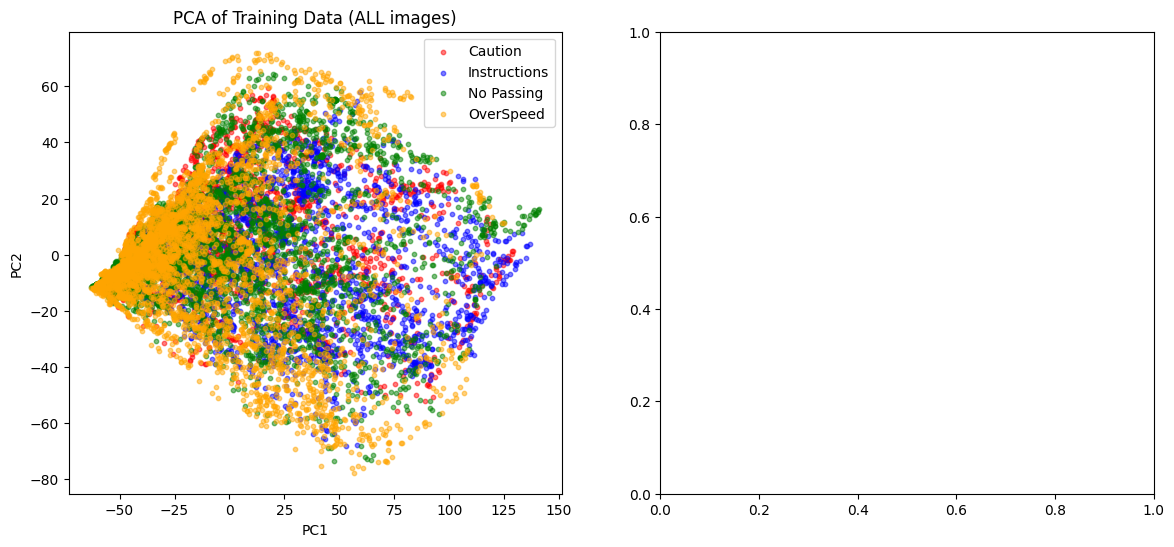

In [31]:
# ============================================
# DEEPER DATA LEAKAGE DIAGNOSIS
# ============================================

print("="*60)
print("DEEP DIAGNOSIS: FINDING THE REAL ISSUE")
print("="*60)

# Check 1: Per-class PCA visualization
print("\n📊 Visualizing class overlap...")
from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PCA on training data
X_flat = X_train.reshape(X_train.shape[0], -1)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_flat)

ax1 = axes[0]
colors = ['red', 'blue', 'green', 'orange']
for i in range(num_classes):
    mask = y_train == i
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[i], label=class_names[i], alpha=0.5, s=10)
ax1.set_title('PCA of Training Data (ALL images)', fontsize=12)
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.legend()

# Check 2: Are the classes actually overlapping?
print("\n📊 Computing class distances...")
from sklearn.metrics.pairwise import euclidean_distances

# Calculate intra-class and inter-class distances
intra_distances = []
inter_distances = []

for i in range(num_classes):
    class_mask = y_train == i
    class_samples = X_flat[class_mask][:100]  # Limit to 100 for speed
    
    # Intra-class distances
    if len(class_samples) > 1:
        intra = euclidean_distances(class_samples).mean()
        intra_distances.append(intra)
    
    # Inter-class distances
    for j in range(i+1, num_classes):
        other_mask = y_train == j
        other_samples = X_flat[other_mask][:100]
        if len(other_samples) > 0:
            inter = euclidean_distances(class_samples, other_samples).mean()
            inter_distances.append(inter)

print(f"Average INTRA-class distance (within same class): {np.mean(intra_distances):.2f}")
print(f"Average INTER-class distance (between different classes): {np.mean(inter_distances):.2f}")

if np.mean(inter_distances) < np.mean(intra_distances):
    print("❌ PROBLEM: Different classes are CLOSER than same classes!")
    print("   Your model cannot learn meaningful distinctions.")
else:
    print("✅ Classes are separated in feature space.")

# Check 3: Test on completely random data
print("\n" + "="*60)
print("TEST ON RANDOM NOISE (should get 25%)")
print("="*60)

# Create random noise images
X_random = np.random.rand(500, 128, 128, 3).astype(np.float32)
y_random_labels = np.random.randint(0, num_classes, 500)

# Train quick model
noise_model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(128,128,3)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

noise_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
noise_model.fit(X_random, y_random_labels, epochs=3, batch_size=32, verbose=0)
noise_loss, noise_acc = noise_model.evaluate(X_random, y_random_labels, verbose=0)
print(f"Model trained and tested on RANDOM NOISE: {noise_acc*100:.2f}% accuracy")
print(f"(Expected: ~25%, Baseline: {100/num_classes:.1f}%)")

if noise_acc > 0.35:
    print("❌ Even random noise gets high accuracy - your model architecture is OVERFITTING!")
else:
    print("✅ Model doesn't overfit on random data.")

# Check 4: Training with shuffled labels on FULL dataset
print("\n" + "="*60)
print("TRAIN ON SHUFFLED LABELS (FULL DATASET)")
print("="*60)

y_full_shuffled = np.random.permutation(y_train)
shuffle_model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

shuffle_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Training on FULL dataset with shuffled labels...")
history_shuffle = shuffle_model.fit(
    X_train[:2000], y_full_shuffled[:2000],
    validation_data=(X_val[:500], y_val[:500]),
    epochs=5,
    batch_size=32,
    verbose=0
)

shuffle_acc = history_shuffle.history['val_accuracy'][-1]
print(f"Validation accuracy with SHUFFLED labels: {shuffle_acc*100:.2f}%")
if shuffle_acc > 35:
    print("❌ CRITICAL: Model achieves {shuffle_acc*100:.1f}% on random labels!")
    print("   This means your model is memorizing background patterns or there's a bug.")
elif shuffle_acc < 30:
    print("✅ Shuffled labels give reasonable accuracy ({shuffle_acc*100:.1f}%)")

print("\n" + "="*60)
print("FINAL DIAGNOSIS")
print("="*60)

if np.mean(inter_distances) < np.mean(intra_distances):
    print("🔴 PROBLEM: Intra-class variation > Inter-class separation")
    print("   Recommendation: Re-examine your dataset. Are classes correctly labeled?")
    print("   Are there similar signs across different classes?")
    
elif shuffle_acc > 0.35:
    print("🔴 PROBLEM: Model overfits to background/location patterns")
    print("   Recommendation: Add more aggressive data augmentation")
    print("   or use different train/validation split strategy")
    
else:
    print("🟡 Your silhouette score is negative but further tests passed.")
    print("   Consider re-running PCA on validation set to compare.")